# Audio Features Analysis

This notebook extracts and analyzes audio features from the MP3 files downloaded from YouTube.

We'll explore:
1. Basic audio properties (duration, sampling rate)
2. Spectral features (spectrograms, MFCCs)
3. Temporal features (beats, tempo, onset detection)
4. High-level features (genre classification, mood detection)
5. Visualizations of these features

In [1]:
# Install required packages
!pip install librosa matplotlib numpy pandas seaborn IPython

   ---------------------------------------- 0.0/260.7 kB ? eta -:--:--
   --------------------------------------- 260.7/260.7 kB 15.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/74.9 kB ? eta -:--:--
   ---------------------------------------- 74.9/74.9 kB ? eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 25.4 MB/s eta 0:00:01
   ------------------------- -------------- 1.8/2.8 MB 19.0 MB/s eta 0:00:01
   ------------------------- -------------- 1.8/2.8 MB 19.0 MB/s eta 0:00:01
   ------------------------------------ --- 2.6/2.8 MB 15.0 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 13.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/64.6 kB ? eta -:--:--
   ---------------------------------------- 64.6/64.6 kB ? eta 0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ------------------------------------ --- 

In [ ]:
from IPython.display import HTML, display

# ใช้ Font ไทยจาก Google Fonts แทนการค้นหาในเครื่อง
display(HTML("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Sarabun:wght@400;700&display=swap');
    body {
        font-family: 'Sarabun', sans-serif !important;
    }
    .output_area pre, .CodeMirror {
        font-family: monospace;
    }
</style>
<script>
    // ตั้งค่าฟอนต์ไทยให้ matplotlib ด้วย
    window.setTimeout(function() {
        if (window.Jupyter && Jupyter.notebook) {
            let cmd = `
                import matplotlib.pyplot as plt
                plt.rcParams['font.family'] = 'Sarabun'
                plt.rcParams['font.sans-serif'] = ['Sarabun', 'DejaVu Sans', 'Arial', 'Tahoma']
                plt.rcParams['font.size'] = 12
            `;
            Jupyter.notebook.kernel.execute(cmd);
        }
    }, 1000);
</script>
"""))

print("Font Sarabun ถูกตั้งค่าแล้ว ข้อความนี้ควรแสดงผลเป็นภาษาไทยได้อย่างถูกต้อง")



Font Sarabun ถูกตั้งค่าแล้ว ข้อความนี้ควรแสดงผลเป็นภาษาไทยได้อย่างถูกต้อง


In [35]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, display
from tqdm.notebook import tqdm
import matplotlib as mpl
import matplotlib.font_manager as fm

# Try to set font that supports Thai characters
# Thai font setup
try:
    import matplotlib.font_manager as fm
    
    # ตรวจสอบว่ามีฟอนต์ไทยหรือไม่ (เพิ่ม 'sarabun' ในการค้นหา)
    thai_fonts = [f for f in fm.findSystemFonts() if any(tf in f.lower() for tf in ['thai', 'tis', 'loma', 'waree', 'garuda', 'noto', 'sarabun'])]
    
    if thai_fonts:
        thai_font = thai_fonts[0]
        print(f"ตั้งค่าฟอนต์ไทยจากเครื่อง: {os.path.basename(thai_font)}")
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = [os.path.basename(thai_font).split('.')[0], 'Sarabun', 'Arial', 'Tahoma']
    else:
        print("ไม่พบฟอนต์ไทยในเครื่อง กำลังใช้ฟอนต์ Sarabun จาก Google Fonts แทน")
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = ['Sarabun', 'Arial', 'Tahoma', 'DejaVu Sans']
except Exception as e:
    print(f"เกิดข้อผิดพลาดในการตั้งค่าฟอนต์: {e}")

# Set up plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_palette('viridis')

ไม่พบฟอนต์ไทยในเครื่อง กำลังใช้ฟอนต์ Sarabun จาก Google Fonts แทน


In [36]:
# แก้ไข cell ที่โหลดไฟล์เพื่อให้แสดงชื่อไทยได้อย่างถูกต้อง
# Directory containing MP3 files
mp3_dir = "downloaded_mp3"

# Get list of MP3 files with proper encoding for Thai characters
mp3_files = [f for f in os.listdir(mp3_dir) if f.endswith('.mp3')]

print(f"Found {len(mp3_files)} MP3 files in '{mp3_dir}' directory.")

# Display first few files
for i, file in enumerate(mp3_files[:5], 1):
    try:
        # แสดงชื่อไฟล์ด้วย Unicode
        print(f"{i}. {file}")
    except UnicodeEncodeError:
        print(f"{i}. <ไม่สามารถแสดงชื่อไฟล์ได้>")
    
if len(mp3_files) > 5:
    print(f"... and {len(mp3_files) - 5} more files")

Found 18 MP3 files in 'downloaded_mp3' directory.
1. กำลังตัดใจ - SERIOUS BACON [ Official MV ].mp3
2. จะกลับไปดีกับเขาก็บอก - SERIOUS BACON [ Official MV ].mp3
3. ถ้าเธอไม่ไหว – SERIOUS BACON x TATTOO COLOUR [Official MV].mp3
4. บอกให้ฟังหน่อยนะ (please tell me) - Serious Copter [ Official MV ].mp3
5. พี่ๆ ตัดแว่นให้หน่อย - SERIOUS BACON [ Official MV ].mp3
... and 13 more files


## 1. Load and Explore Audio Data

Let's load a sample audio file and examine its basic properties.

In [37]:
# Function to load audio file and extract basic properties
def load_audio_file(file_path, sr=22050):
    """Load an audio file and return its waveform and sample rate"""
    try:
        # Load the audio file
        y, sr = librosa.load(file_path, sr=sr)
        return y, sr
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None

# Load the first file as a sample
if mp3_files:
    sample_file = os.path.join(mp3_dir, mp3_files[0])
    print(f"Loading sample file: {mp3_files[0]}")
    
    # Load audio
    y, sr = load_audio_file(sample_file)
    
    if y is not None:
        # Display basic properties
        duration = librosa.get_duration(y=y, sr=sr)
        print(f"Sample rate: {sr} Hz")
        print(f"Duration: {duration:.2f} seconds ({int(duration // 60):02d}:{int(duration % 60):02d})")
        print(f"Number of samples: {len(y)}")
        print(f"Min amplitude: {y.min():.4f}")
        print(f"Max amplitude: {y.max():.4f}")
        
        # Play a short segment of the audio
        duration_to_play = min(10, duration)  # Play up to 10 seconds
        samples_to_play = int(duration_to_play * sr)
        display(Audio(y[:samples_to_play], rate=sr))
else:
    print("No MP3 files found in the directory.")

Loading sample file: กำลังตัดใจ - SERIOUS BACON [ Official MV ].mp3
Sample rate: 22050 Hz
Duration: 265.49 seconds (04:25)
Number of samples: 5853953
Min amplitude: -0.9735
Max amplitude: 1.0332


## 2. Visualize the Waveform and Spectrogram

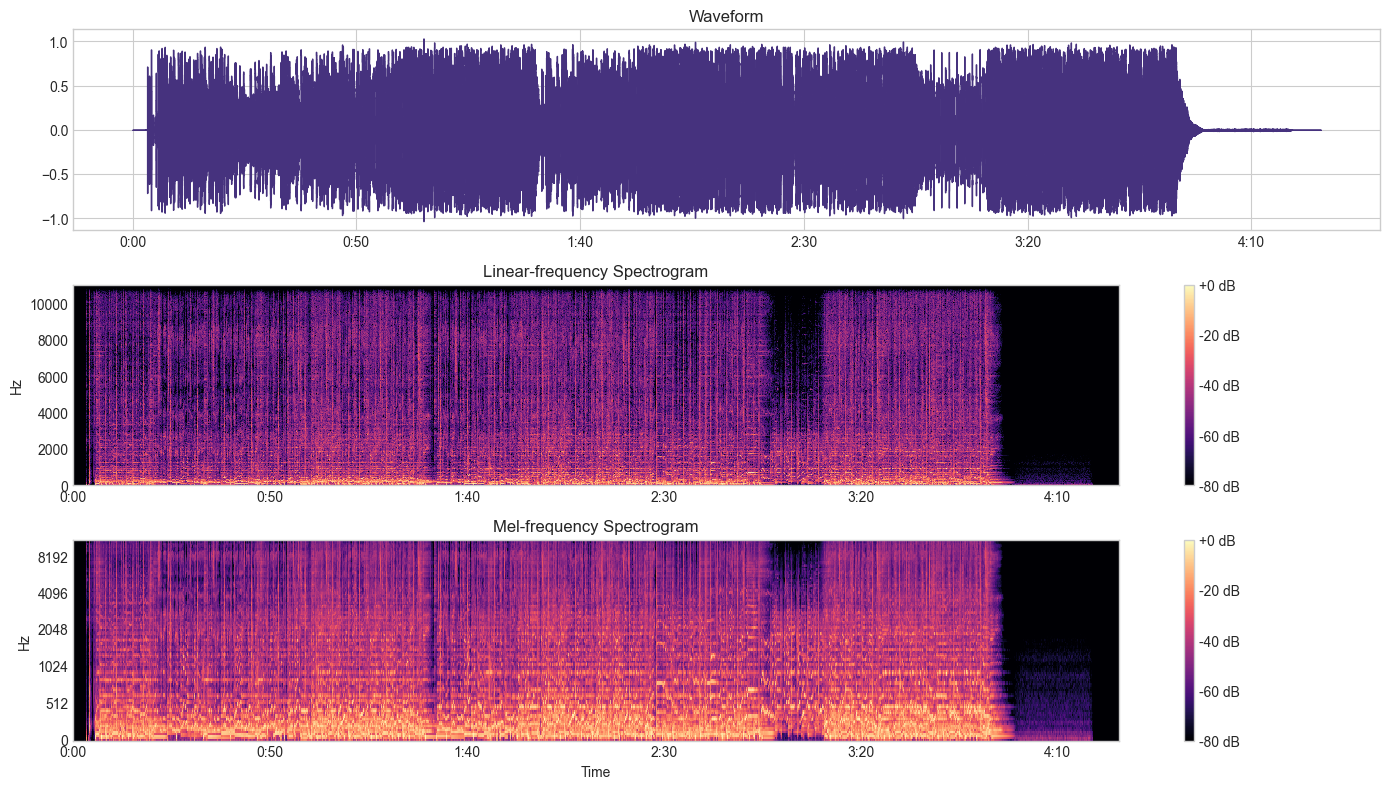

In [38]:
if y is not None:
    plt.figure(figsize=(14, 8))
    
    # Plot waveform
    plt.subplot(3, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title('Waveform')
    plt.xlabel('')
    
    # Compute and plot the spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    plt.subplot(3, 1, 2)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Linear-frequency Spectrogram')
    plt.xlabel('')
    
    # Compute and plot mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    plt.subplot(3, 1, 3)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-frequency Spectrogram')
    
    plt.tight_layout()
    plt.show()

## 3. Extract Audio Features

Let's extract various features from the audio:

In [39]:
def extract_features(y, sr):
    """Extract various audio features from the waveform"""
    features = {}
    
    # Spectral features
    features['mfcc'] = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features['spectral_centroid'] = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    features['spectral_bandwidth'] = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    features['spectral_rolloff'] = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    features['spectral_contrast'] = librosa.feature.spectral_contrast(y=y, sr=sr)
    
    # Rhythm features
    tempo, beats = librosa.beat.beat_track(y=y, sr=sr)
    features['tempo'] = tempo
    features['beats'] = beats
    
    # Harmonic and percussive components
    harmonic, percussive = librosa.effects.hpss(y)
    features['harmonic'] = harmonic
    features['percussive'] = percussive
    
    # Chroma features
    features['chroma'] = librosa.feature.chroma_stft(y=harmonic, sr=sr)
    
    # Tonnetz (tonal centroid features)
    features['tonnetz'] = librosa.feature.tonnetz(y=harmonic, sr=sr)
    
    # Zero crossing rate
    features['zero_crossing_rate'] = librosa.feature.zero_crossing_rate(y)[0]
    
    # RMS energy
    features['rms'] = librosa.feature.rms(y=y)[0]
    
    return features

# Extract features for the sample audio
if y is not None:
    features = extract_features(y, sr)
    print("Extracted features:")
    for name, feature in features.items():
        if isinstance(feature, np.ndarray):
            print(f"{name}: shape {feature.shape}")
        else:
            print(f"{name}: {feature}")

Extracted features:
mfcc: shape (13, 11434)
spectral_centroid: shape (11434,)
spectral_bandwidth: shape (11434,)
spectral_rolloff: shape (11434,)
spectral_contrast: shape (7, 11434)
tempo: shape (1,)
beats: shape (266,)
harmonic: shape (5853953,)
percussive: shape (5853953,)
chroma: shape (12, 11434)
tonnetz: shape (6, 11434)
zero_crossing_rate: shape (11434,)
rms: shape (11434,)


## 4. Visualize the Features

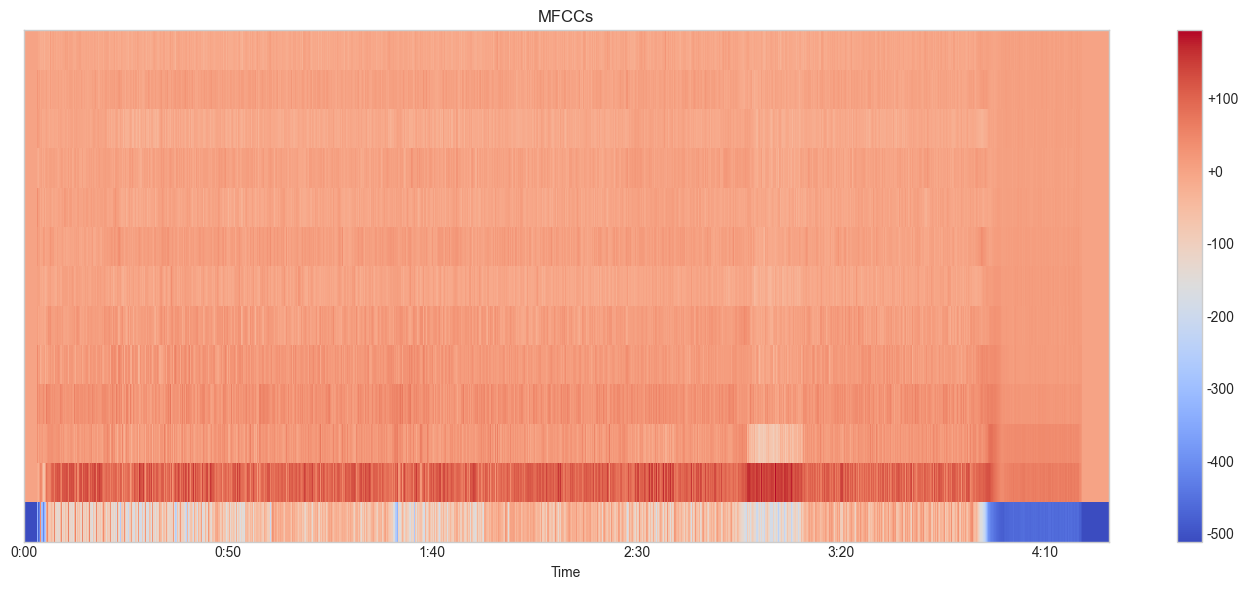

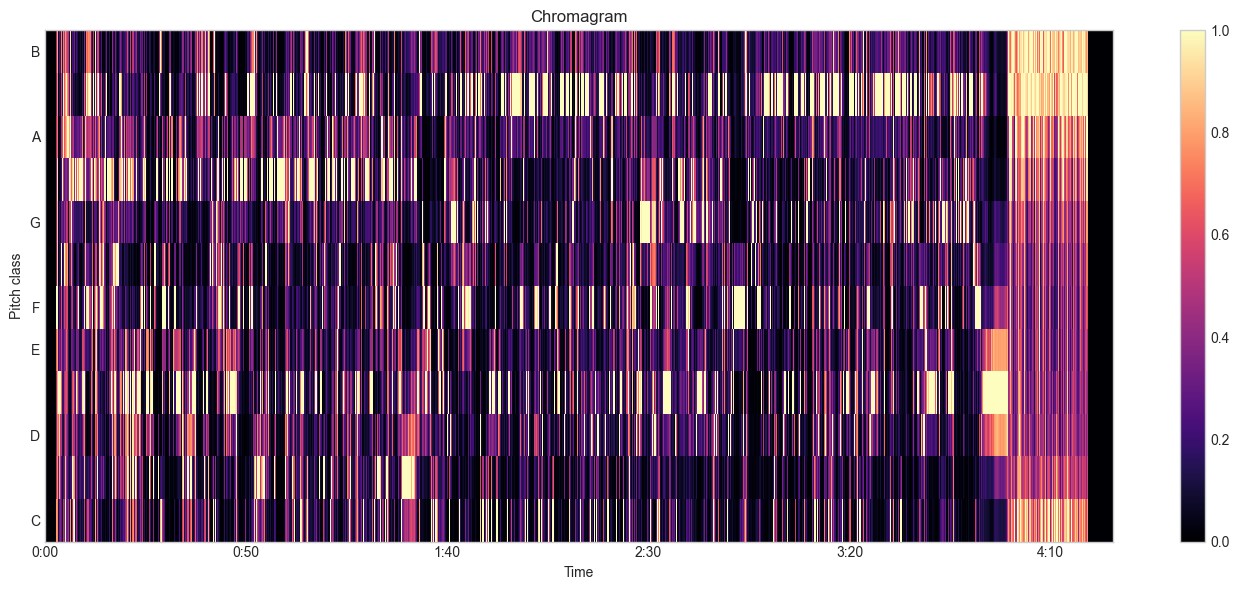

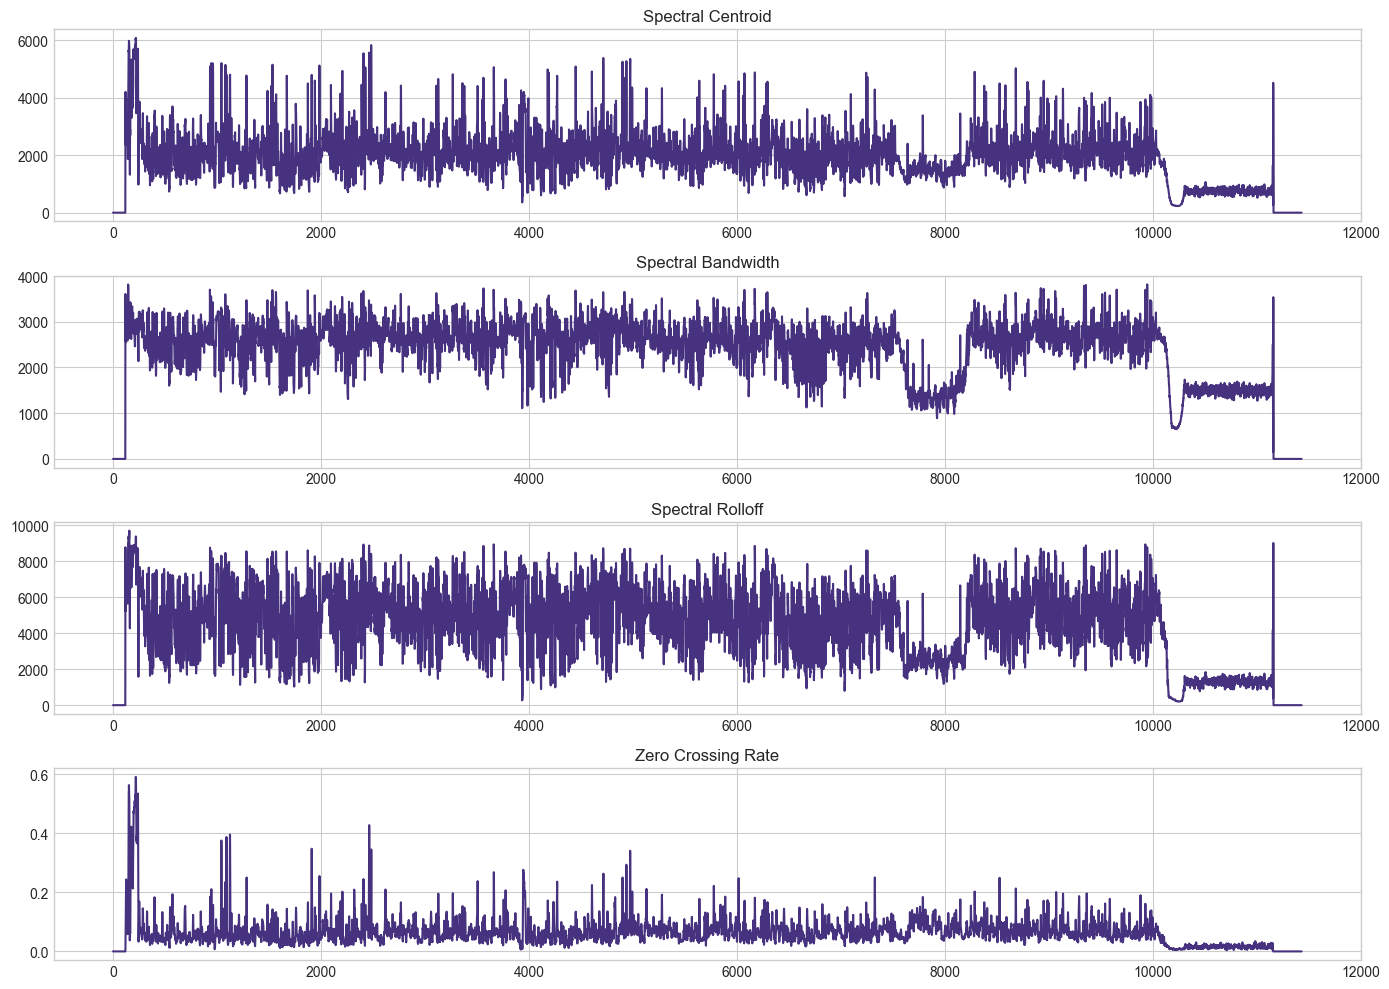

In [21]:
if y is not None:
    # Visualize MFCCs
    plt.figure(figsize=(14, 6))
    librosa.display.specshow(features['mfcc'], sr=sr, x_axis='time')
    plt.colorbar(format='%+2.0f')
    plt.title('MFCCs')
    plt.tight_layout()
    plt.show()
    
    # Visualize chroma features
    plt.figure(figsize=(14, 6))
    librosa.display.specshow(features['chroma'], sr=sr, y_axis='chroma', x_axis='time')
    plt.colorbar()
    plt.title('Chromagram')
    plt.tight_layout()
    plt.show()
    
    # Plot spectral features over time
    plt.figure(figsize=(14, 10))
    
    plt.subplot(4, 1, 1)
    plt.plot(features['spectral_centroid'])
    plt.title('Spectral Centroid')
    plt.xlabel('')
    
    plt.subplot(4, 1, 2)
    plt.plot(features['spectral_bandwidth'])
    plt.title('Spectral Bandwidth')
    plt.xlabel('')
    
    plt.subplot(4, 1, 3)
    plt.plot(features['spectral_rolloff'])
    plt.title('Spectral Rolloff')
    plt.xlabel('')
    
    plt.subplot(4, 1, 4)
    plt.plot(features['zero_crossing_rate'])
    plt.title('Zero Crossing Rate')
    
    plt.tight_layout()
    plt.show()

## 5. Visualize Beat Detection

C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\1699574449.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Chulin\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


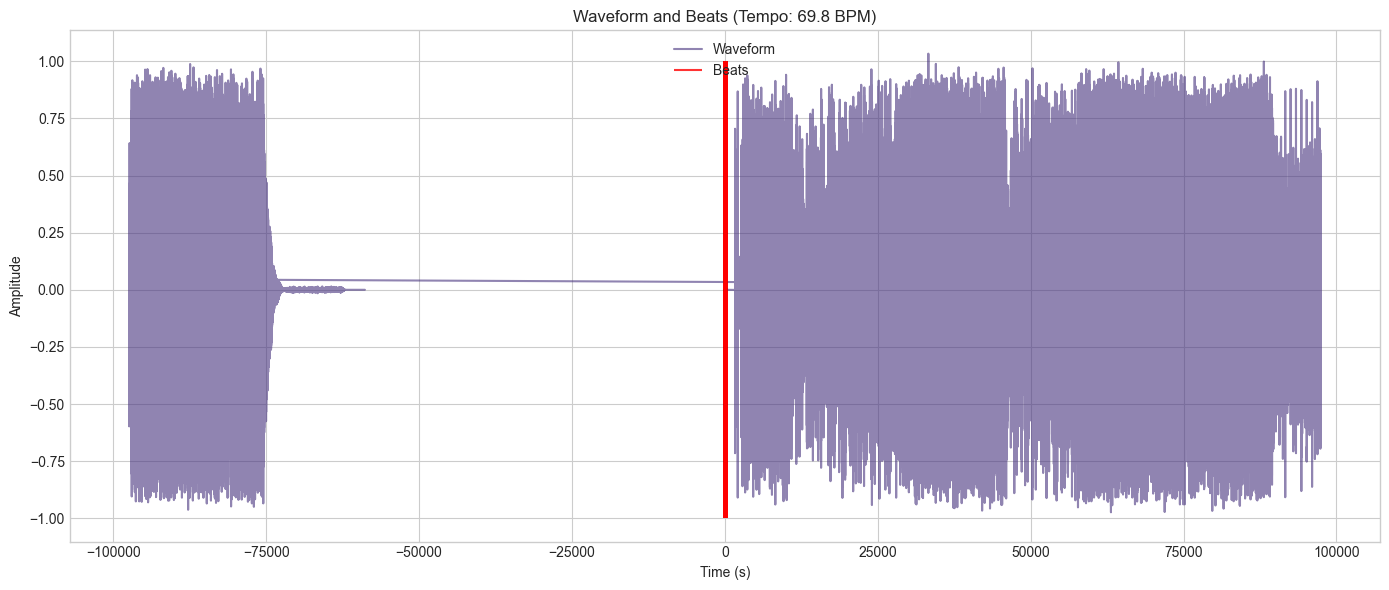

In [40]:
if y is not None:
    plt.figure(figsize=(14, 6))
    
    # First plot the waveform
    times = librosa.times_like(y, sr=sr)
    plt.plot(times, y, label='Waveform', alpha=0.6)
    
    # Then plot the beat frames
    beat_times = librosa.frames_to_time(features['beats'], sr=sr)
    plt.vlines(beat_times, -1, 1, color='r', alpha=0.8, label='Beats')
    
    plt.legend()
    # Fix: Convert tempo to a scalar if it's an array
    tempo_value = features["tempo"].item() if hasattr(features["tempo"], "item") else features["tempo"]
    plt.title(f'Waveform and Beats (Tempo: {tempo_value:.1f} BPM)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

## 6. Compare Multiple Audio Files

Now let's extract summary features from all files and compare them.

In [41]:
def extract_summary_features(file_path):
    """Extract summary features from an audio file"""
    try:
        # ดึงชื่อไฟล์ (อาจมีภาษาไทย)
        file_name = os.path.basename(file_path)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=22050)
        
        # Extract features
        features = {}
        
        # Basic properties
        features['duration'] = librosa.get_duration(y=y, sr=sr)
        
        # Spectral features (mean and std)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            features[f'mfcc{i+1}_mean'] = np.mean(mfccs[i])
            features[f'mfcc{i+1}_std'] = np.std(mfccs[i])
        
        features['spectral_centroid_mean'] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)[0])
        features['spectral_bandwidth_mean'] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)[0])
        features['spectral_rolloff_mean'] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)[0])
        features['zero_crossing_rate_mean'] = np.mean(librosa.feature.zero_crossing_rate(y)[0])
        
        # Rhythm features
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        # Fix: Convert tempo to scalar
        features['tempo'] = float(tempo)
        
        # Energy
        features['rms_mean'] = np.mean(librosa.feature.rms(y=y)[0])
        
        return features
    
    except Exception as e:
        print(f"Error processing {os.path.basename(file_path)}: {e}")
        return None

# Process all files (limit to first 10 for demonstration)
max_files = min(18, len(mp3_files))
all_features = []
all_filenames = []

print(f"Processing {max_files} audio files...")
for i, file in enumerate(mp3_files[:max_files]):
    try:
        file_path = os.path.join(mp3_dir, file)
        features = extract_summary_features(file_path)
        
        if features:
            all_features.append(features)
            all_filenames.append(file)
            print(f"✓ {i+1}/{max_files}: {file}")
        else:
            print(f"✗ {i+1}/{max_files}: Failed to extract features from {file}")
            
    except Exception as e:
        print(f"✗ {i+1}/{max_files}: Error processing {file}: {e}")

# Create a DataFrame with the features
if all_features:
    features_df = pd.DataFrame(all_features)
    features_df['filename'] = all_filenames
    
    print(f"\nExtracted features from {len(all_features)} audio files")
    display(features_df.head())
else:
    print("No features were successfully extracted.")

Processing 18 audio files...


C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\3694582530.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features['tempo'] = float(tempo)


✓ 1/18: กำลังตัดใจ - SERIOUS BACON [ Official MV ].mp3
✓ 2/18: จะกลับไปดีกับเขาก็บอก - SERIOUS BACON [ Official MV ].mp3
✓ 3/18: ถ้าเธอไม่ไหว – SERIOUS BACON x TATTOO COLOUR [Official MV].mp3
✓ 4/18: บอกให้ฟังหน่อยนะ (please tell me) - Serious Copter [ Official MV ].mp3
✓ 5/18: พี่ๆ ตัดแว่นให้หน่อย - SERIOUS BACON [ Official MV ].mp3
✓ 6/18: มีปัญหาปรึกษาดาว - SERIOUS BACON [ Official Audio ].mp3
✓ 7/18: รักเขาแทนฉันที (Promise Me) - SERIOUS BACON [Official MV].mp3
✓ 8/18: หากว่าฉัน - SERIOUS BACON [Official MV].mp3
✓ 9/18: อย่าไปรักเขาเลยเธอ (Someone Who Cares) - SERIOUS BACON [Official MV].mp3
✓ 10/18: เธอ ๆ เพื่อนเราชอบ (Guess Who？) – SERIOUS BACON [Official MV].mp3
✓ 11/18: เบื้องหลังครั้งแรก! mv #พี่ๆตัดแว่นให้หน่อย สนุกสุดป่วนกวนทั้งกองถ่าย ｜ Serious Bacon.mp3
✓ 12/18: เพื่อนดีเด่น (BEST FRIEND 4EVER) - SERIOUS BACON [Official MV].mp3
✓ 13/18: แป๊บนึง (Can you stay？) - SERIOUS BACON feat. Whal & Dolph [Official MV].mp3
✓ 14/18: แฟนฉัน (Love Ads) - SERIOUS BACON [Official MV].mp3


,duration,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,mfcc4_mean,mfcc4_std,mfcc5_mean,...,mfcc12_std,mfcc13_mean,mfcc13_std,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zero_crossing_rate_mean,tempo,rms_mean,filename
0,265.485397,-119.967163,146.083069,92.522926,34.592018,16.511719,23.723444,27.620523,13.941915,15.780362,...,7.385362,-6.306170,7.842930,1895.662659,2354.112980,4319.497646,0.065118,69.837416,0.214104,กำลังตัดใจ - SERIOUS BACON [ Official MV ].mp3
1,239.281678,-99.804726,109.714928,99.957901,34.032703,17.674797,20.350027,25.258698,16.650501,12.200636,...,8.598104,-7.625148,8.405098,2109.403662,2570.104513,4705.896006,0.080197,135.999178,0.216607,จะกลับไปดีกับเขาก็บอก - SERIOUS BACON [ Offici...
2,293.013333,-59.906784,77.246338,102.623260,28.592718,2.663399,19.812422,31.935539,14.256721,3.808713,...,7.997442,-4.623960,7.358609,2047.900656,2361.642944,4429.570986,0.081635,107.666016,0.232363,ถ้าเธอไม่ไหว – SERIOUS BACON x TATTOO COLOUR [...
3,227.776009,-65.192993,88.384193,94.053444,31.042566,7.994908,20.386168,31.634922,16.011515,9.999273,...,8.522205,-3.750997,8.561598,2170.089666,2486.693762,4754.794653,0.082065,95.703125,0.243476,บอกให้ฟังหน่อยนะ (please tell me) - Serious Co...
4,252.288027,-118.427483,109.922440,103.215523,39.257965,13.377384,28.851133,35.531509,20.211264,12.931036,...,10.181304,-4.405802,8.695003,1806.094332,2251.869763,3857.279179,0.067055,151.999081,0.227512,พี่ๆ ตัดแว่นให้หน่อย - SERIOUS BACON [ Officia...


## 7. Visualize Feature Comparisons

บันทึกข้อมูลเรียบร้อยแล้วที่ audio_features_20250417_230612.csv

ตัวอย่างข้อมูลที่บันทึก:


,filename,duration,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,mfcc4_mean,mfcc4_std,...,mfcc12_mean,mfcc12_std,mfcc13_mean,mfcc13_std,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zero_crossing_rate_mean,tempo,rms_mean
0,กำลังตัดใจ - SERIOUS BACON [ Official MV ].mp3,265.485397,-119.967163,146.083069,92.522926,34.592018,16.511719,23.723444,27.620523,13.941915,...,2.369092,7.385362,-6.306170,7.842930,1895.662659,2354.112980,4319.497646,0.065118,69.837416,0.214104
1,จะกลับไปดีกับเขาก็บอก - SERIOUS BACON [ Offici...,239.281678,-99.804726,109.714928,99.957901,34.032703,17.674797,20.350027,25.258698,16.650501,...,-0.500314,8.598104,-7.625148,8.405098,2109.403662,2570.104513,4705.896006,0.080197,135.999178,0.216607
2,ถ้าเธอไม่ไหว – SERIOUS BACON x TATTOO COLOUR [...,293.013333,-59.906784,77.246338,102.623260,28.592718,2.663399,19.812422,31.935539,14.256721,...,1.322622,7.997442,-4.623960,7.358609,2047.900656,2361.642944,4429.570986,0.081635,107.666016,0.232363
3,บอกให้ฟังหน่อยนะ (please tell me) - Serious Co...,227.776009,-65.192993,88.384193,94.053444,31.042566,7.994908,20.386168,31.634922,16.011515,...,2.699184,8.522205,-3.750997,8.561598,2170.089666,2486.693762,4754.794653,0.082065,95.703125,0.243476
4,พี่ๆ ตัดแว่นให้หน่อย - SERIOUS BACON [ Officia...,252.288027,-118.427483,109.922440,103.215523,39.257965,13.377384,28.851133,35.531509,20.211264,...,2.425869,10.181304,-4.405802,8.695003,1806.094332,2251.869763,3857.279179,0.067055,151.999081,0.227512


C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\2197730484.py:46: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) Arial.
  plt.tight_layout(pad=2)
C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\2197730484.py:46: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) Arial.
  plt.tight_layout(pad=2)
C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\2197730484.py:46: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout(pad=2)
C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\2197730484.py:46: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) Arial.
  plt.tight_layout(pad=2)
C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\2197730484.py:46: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) Arial.
  plt.tight_layout(pad=2)
C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\2197730484.py:46: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) 

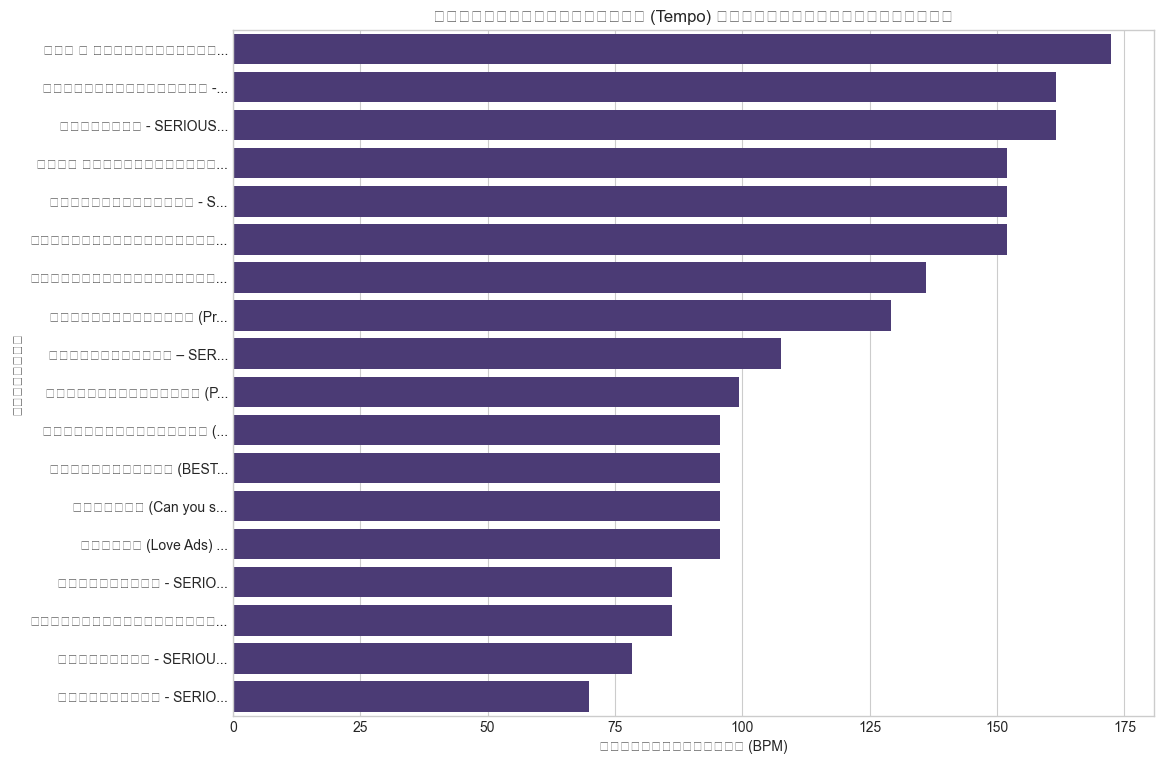

In [43]:
# ปรับปรุงส่วนที่แสดงตัวอย่างในกราฟ
if 'features_df' in locals() and not features_df.empty:
    # ย้ายคอลัมน์ filename ไปเป็นคอลัมน์แรก
    cols = ['filename'] + [col for col in features_df.columns if col != 'filename']
    features_df = features_df[cols]
    features_df['tempo'] = features_df['tempo'].astype(float)
    
    # บันทึกข้อมูลลงไฟล์ CSV ด้วย encoding ที่รองรับภาษาไทย
    from datetime import datetime

    # Append a timestamp to the filename to avoid conflicts
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_csv = f'audio_features_{timestamp}.csv'
    features_df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"บันทึกข้อมูลเรียบร้อยแล้วที่ {output_csv}")
    
    print("\nตัวอย่างข้อมูลที่บันทึก:")
    display(features_df.head())
    
    # สร้างกราฟเปรียบเทียบ tempo
    plt.figure(figsize=(12, 8))
    
    # เรียงตาม tempo
    tempo_df = features_df.sort_values('tempo', ascending=False)
    
    # สร้างชื่อย่อสำหรับแสดงในกราฟ
    shortened_names = []
    for name in tempo_df['filename']:
        try:
            # แสดงชื่อไฟล์สั้นๆ
            base_name = os.path.splitext(name)[0]
            shortened = base_name if len(base_name) <= 20 else base_name[:18] + '...'
            shortened_names.append(shortened)
        except:
            shortened_names.append('Unknown')
    
    tempo_df['short_name'] = shortened_names
    
    # วาดกราฟแท่งด้วย short_name แทน filename
    ax = sns.barplot(x='tempo', y='short_name', data=tempo_df)
    plt.title('เปรียบเทียบจังหวะ (Tempo) ของไฟล์เสียงทั้งหมด')
    plt.xlabel('ความเร็วจังหวะ (BPM)')
    plt.ylabel('ชื่อไฟล์')
    
    # ขยายพื้นที่แสดงผลให้มีที่แสดงชื่อไฟล์ภาษาไทยมากขึ้น
    plt.tight_layout(pad=2)
    plt.show()

## 8. Principal Component Analysis (PCA) for Dimensionality Reduction

C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\1839450468.py:37: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\1839450468.py:37: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\1839450468.py:37: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\1839450468.py:37: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\1839450468.py:37: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Chulin\AppData\Local\Temp\ipykernel_15376\1839450468.py:37: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s)

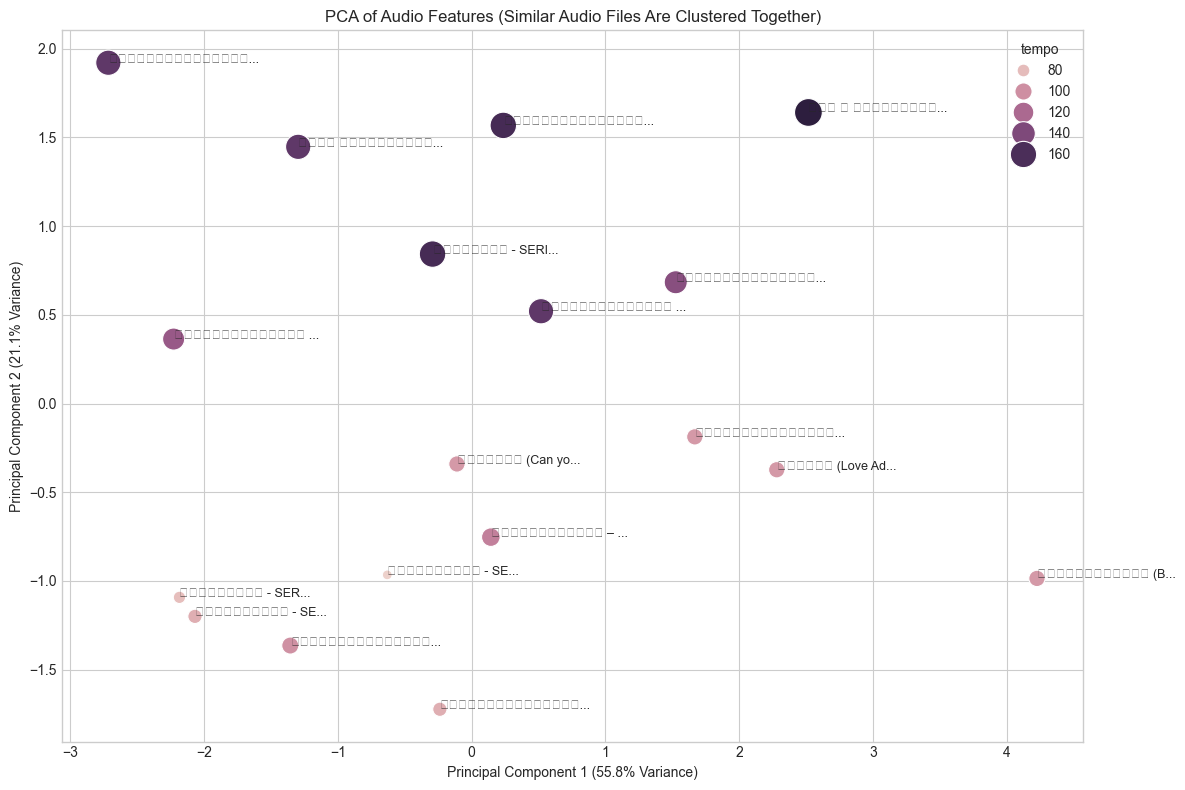

In [44]:
if 'features_df' in locals() and not features_df.empty and len(features_df) > 3:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    
    # Select features for PCA
    feature_cols = features_df.select_dtypes(include=['float64']).columns.tolist()
    
    if len(feature_cols) > 0:
        # Standardize the features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(features_df[feature_cols])
        
        # Apply PCA
        pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
        pca_result = pca.fit_transform(scaled_features)
        
        # Create DataFrame for plotting
        pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
        pca_df['filename'] = features_df['filename']
        pca_df['tempo'] = features_df['tempo']
        
        # Plot PCA results
        plt.figure(figsize=(12, 8))
        sns.scatterplot(x='PC1', y='PC2', hue='tempo', size='tempo', sizes=(50, 400), data=pca_df)
        
        # Add file names as labels
        for i, row in pca_df.iterrows():
            plt.text(
                row['PC1'], row['PC2'],
                os.path.splitext(row['filename'])[0][:15] + '...' if len(os.path.splitext(row['filename'])[0]) > 15 else os.path.splitext(row['filename'])[0],
                fontsize=9
            )
        
        plt.title('PCA of Audio Features (Similar Audio Files Are Clustered Together)')
        plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
        plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
        plt.tight_layout()
        plt.show()

## 9. Create Audio Fingerprints and Similarity Matrix

Creating audio fingerprints for 18 files...
✓ 1/18
✓ 2/18
✓ 3/18
✓ 4/18
✓ 5/18
✓ 6/18
✓ 7/18
✓ 8/18
✓ 9/18
✓ 10/18
✓ 11/18
✓ 12/18
✓ 13/18
✓ 14/18
✓ 15/18
✓ 16/18
✓ 17/18
✓ 18/18


c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  fig.canvas.dr

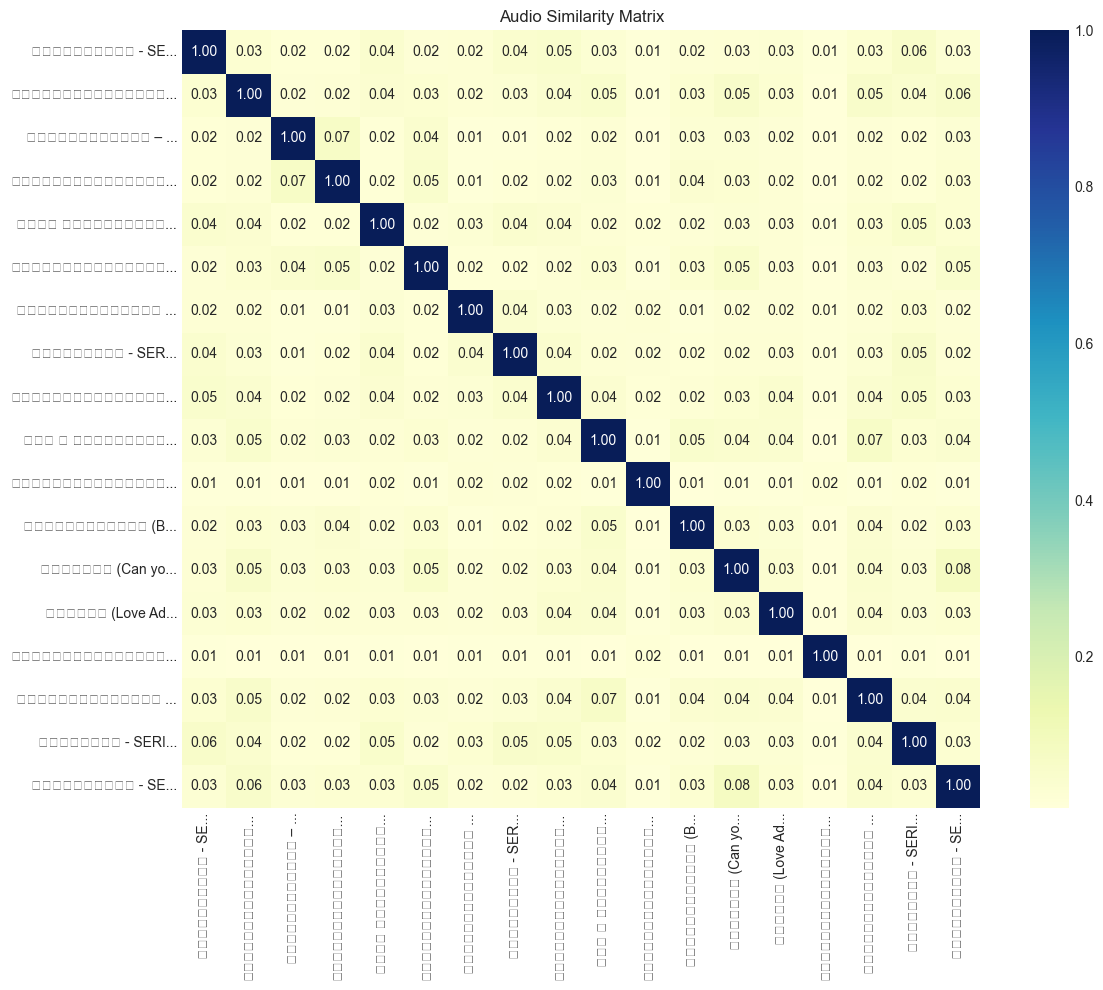

Most similar audio files:
1. แป๊บนึง (Can you stay？) - SERIOUS BACON feat. Whal & Dolph [Official MV].mp3
2. ไม่อยากฟัง - SERIOUS BACON [ Official MV ].mp3
Similarity score: 0.0804


In [45]:
if len(mp3_files) > 1:
    from scipy.spatial.distance import cdist
    
    # Function to create an audio fingerprint using MFCCs
    def create_fingerprint(file_path):
        try:
            y, sr = librosa.load(file_path, sr=22050)
            # Extract MFCCs and take the mean across time
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
            fingerprint = np.mean(mfccs, axis=1)
            return fingerprint
        except Exception as e:
            print(f"Error creating fingerprint for {file_path}: {e}")
            return None
    
    # Create fingerprints for all files (limit to first 15 for demonstration)
    max_files_fingerprint = min(18, len(mp3_files))
    fingerprints = []
    fingerprint_files = []
    
    print(f"Creating audio fingerprints for {max_files_fingerprint} files...")
    for i, file in enumerate(mp3_files[:max_files_fingerprint]):
        file_path = os.path.join(mp3_dir, file)
        fingerprint = create_fingerprint(file_path)
        
        if fingerprint is not None:
            fingerprints.append(fingerprint)
            fingerprint_files.append(file)
            print(f"✓ {i+1}/{max_files_fingerprint}")
    
    # Calculate similarity matrix
    if len(fingerprints) > 1:
        fingerprints_array = np.array(fingerprints)
        
        # Calculate Euclidean distance between fingerprints
        distance_matrix = cdist(fingerprints_array, fingerprints_array, metric='euclidean')
        
        # Convert to similarity (inverse of distance)
        similarity_matrix = 1 / (1 + distance_matrix)
        
        # Plot similarity matrix
        plt.figure(figsize=(12, 10))
        sns.heatmap(
            similarity_matrix, 
            annot=True, 
            fmt=".2f", 
            xticklabels=[os.path.splitext(f)[0][:15] + '...' if len(os.path.splitext(f)[0]) > 15 else os.path.splitext(f)[0] for f in fingerprint_files],
            yticklabels=[os.path.splitext(f)[0][:15] + '...' if len(os.path.splitext(f)[0]) > 15 else os.path.splitext(f)[0] for f in fingerprint_files],
            cmap="YlGnBu"
        )
        plt.title('Audio Similarity Matrix')
        plt.tight_layout()
        plt.show()
        
        # Find most similar pair
        np.fill_diagonal(similarity_matrix, 0)  # Ignore self-similarity
        max_similarity_idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
        file1, file2 = fingerprint_files[max_similarity_idx[0]], fingerprint_files[max_similarity_idx[1]]
        similarity_score = similarity_matrix[max_similarity_idx]
        
        print(f"Most similar audio files:")
        print(f"1. {file1}")
        print(f"2. {file2}")
        print(f"Similarity score: {similarity_score:.4f}")
    else:
        print("Not enough fingerprints were created for similarity analysis.")

## 10. Save Features to CSV for Further Analysis

In [46]:
if 'features_df' in locals() and not features_df.empty:
    # Save features to CSV
    output_csv = 'audio_features.csv'
    features_df.to_csv(output_csv, index=False)
    print(f"Saved audio features to {output_csv}")

Saved audio features to audio_features.csv
